<h1 style="color: #ADD8E6;">Complementaria 3: Cadenas de Markov en Python I</h1>

<h2 style="color: #ADD8E6;">Introducción a jmarkov</h2>


En esta sección construiremos una cadena de Markov en tiempo continuo (CMTC) sencilla con 3 estados. La idea de este ejercicio es ilustrar, de manera compacta, los principales cálculos que podemos realizar con `jmarkov`, tanto estructurales como probabilísticos.

Consideremos una cadena con variable $X\left(t\right)$ y un espacio de estados $S_x = \{1,2,3\}$. Las transiciones entre estados están gobernadas por la siguiente matriz generadora:


$$
Q_{(i,j)} = \begin{pmatrix}
-3 & 2 & 1 \\
1 & -4 & 3 \\
2 & 1 & -3
\end{pmatrix}
$$


> **Recordemos que en una CMTC**
> - Las filas de $Q$ suman cero.
> - Los elementos fuera de la diagonal son no negativos.
> - La diagonal es negativa y representa la tasa de salida del estado.


In [95]:
import numpy as np
from jmarkov.ctmc import ctmc

# Definimos la matriz generadora
Q = np.array([
    [-3, 2, 1],
    [1, -4, 3],
    [2, 1, -3]
])

# Verificamos que las filas sumen cero
print("Suma por filas:", Q.sum(axis=1))

# Creamos la cadena de jmarkov continua
cadena = ctmc(Q)

Suma por filas: [0 0 0]


Podemos verificar propiedades importantes de la cadena.

In [96]:
print("Número de estados:", cadena.n_states)

print("¿Es irreducible?:", cadena.is_irreducible())

print("¿Es ergódica?:", cadena.is_ergodic())

Número de estados: 3
¿Es irreducible?: True
¿Es ergódica?: True



<h3 style="color: #ADD8E6;">Análisis transitorio</h3>

Podemos calcular la distribución en un instante $ t $ dado un estado inicial indicado con un vector de estados inciales $ \overrightarrow{\pi}(0) $.

$$
\overrightarrow{\pi}(t) = \overrightarrow{\pi}(0)e^{Qt},
$$

Supongamos que la cadena inicia en el estado 0 (esto lo indicamos con un 1 en el estado correspondiente):

$$
\overrightarrow{\pi}(t) = (1, 0, 0)
$$

`jmarkov` recibe como parámetros `t` y `alpha` para encontrar el vector de probabilidades $\overrightarrow{\pi}(t)$. Estos son el tiempo total que se esta evaluando y el vector de estados iniciales respectivamente. 

In [97]:
pi_0 = np.array([1, 0, 0])
t = 2

p_t = cadena.transient_probabilities(t=t, alpha=pi_0)

print(f"Distribución en t={t}:")
print(p_t)
print(" ")

# Asi por ejemplo, la probabilidad de estar en el estado 1 dado que empezamos en el estado 0,
#  luego de que transcurran t = 2 uniades de tiempo es:
print("La probabilidad de estar en el estado 1 en t=2 es", round(p_t[1], 3))

Distribución en t=2:
[0.34615261 0.26926285 0.38458454]
 
La probabilidad de estar en el estado 1 en t=2 es 0.269


<h3 style="color: #ADD8E6;">Probabilidades en estado estable</h3>

Si la cadena es ergódica, existe una distribución estacionaria $ \pi $ tal que:

$$
\overrightarrow{\pi}\mathbb{Q =}\overrightarrow{0},
$$

$$
\sum_{i \in S}^{}\pi_{i} = 1
$$



Podemos calcularla directamente:

In [98]:
pi = cadena.steady_state()

print("Distribución estacionaria:")
print(pi)
print(" ")

# Asi por ejemplo, la probabilidad de estar en el estado 1 en el largo plazo es:
print("La probabilidad de estar en el estado 1 en el largo plazo es", round(pi[1], 3))

Distribución estacionaria:
[0.34615385 0.26923077 0.38461538]
 
La probabilidad de estar en el estado 1 en el largo plazo es 0.269


<h3 style="color: #ADD8E6;">Tiempo de primera pasada</h3>

El tiempo promedio de primera pasada (hitting time) desde un estado inicial hacia un estado objetivo puede calcularse al escribir $m_{i,j}$

$$
m_{i,j} = \frac{1}{-q_{ii}}\ \left( 1 + \sum_{k \neq j}^{}{q_{ik}m_{k,j}} \right)
$$

Esta expresión permite encontrar el tiempo $m_{i,j}$ a partir de los otros tiempos $m_{k,j}$. Matemáticamente para encontrar $m_{i,j}$ hay que solucionar el sistema de ecuaciones simultaneas asociado. `jmarkov` ya implementa una función para encontrar los tiempos de primera pasada a un estado objetivo.

Por ejemplo, el tiempo promedio para llegar al estado 2 comenzando desde el estado 1 se calcula de la siguiente forma:

In [99]:
# Se define un array con los nombres de los estados
estados = ['0', '1', '2']
estados = np.array(estados)

estado_inicial = np.where(estados == '1')
estado_futuro = np.where(estados == '2')

# Calcular el tiempo
fpts = cadena.first_passage_time(estado_futuro)
# No tiene sentido calcular el tiempo de primera pasada al estado 2 desde el estado 2
# Por lo tanto, el arreglo que se regresa es de n-1 estados.
print("arreglo de tiempos de primera pasada al estado 2:")
print(fpts)
print(" ")

# La variable estado_inicial contiene el índice del estado '1', que es el estado desde el cual 
# queremos calcular el tiempo de primera pasada al estado '2'.
print("indice del estado inicial:", estado_inicial)
print(" ")

# Indexamos el tiempo de primera pasada desde el estado '1' al estado '2' utilizando el índice obtenido
# utilizamos [0][0] para obtener el numero directamente del array
tiempo_1_2 = fpts[estado_inicial][0][0]
print("El tiempo de primera pasada desde el estado 1 al estado 2 es:", round(tiempo_1_2, 3))

arreglo de tiempos de primera pasada al estado 2:
[[0.6]
 [0.4]]
 
indice del estado inicial: (array([1]),)
 
El tiempo de primera pasada desde el estado 1 al estado 2 es: 0.4


<h3 style="color: #ADD8E6;">Tiempo de ocupación</h3>

En una cadena de Markov en tiempo continuo, el **tiempo de ocupación** mide cuánto tiempo, en promedio, el proceso pasa en cada estado durante un intervalo finito $[0,t]$.

$$
\mathbf{M}^{t} = \int_{0}^{t}{e^{\mathbf{Q}u}du}
$$

En la matriz resultante:

- Cada fila corresponde al estado inicial.
- Cada columna corresponde al estado donde se acumula el tiempo.

Por lo tanto para nuestro ejemplo, la matriz devuelta por `occupation_time(T)` tiene la forma:

$$
\mathbf{M}^{t} =
\begin{pmatrix}
\text{Tiempo desde 0 en 0} & \text{Tiempo desde 0 en 1} & \text{Tiempo desde 0 en 2} \\
\text{Tiempo desde 1 en 0} & \text{Tiempo desde 1 en 1} & \text{Tiempo desde 1 en 2} \\
\text{Tiempo desde 2 en 0} & \text{Tiempo desde 2 en 1} & \text{Tiempo desde 2 en 2}
\end{pmatrix}
$$

In [93]:

tiempo_ocupacion = cadena.occupation_time(T=4)

print("Tiempo esperado en cada estado en 2 unidades de tiempo:")
print(tiempo_ocupacion)
print(" ")

sum_tiempo_ocupacion = tiempo_ocupacion.sum(axis=1)
print("Suma del tiempo de ocupación por filas:", sum_tiempo_ocupacion)
print(" ")

print("Tiempo en 2 desde 1:", round(tiempo_ocupacion[1][2], 3))

Tiempo esperado en cada estado en 2 unidades de tiempo:
[[1.52070832 1.0502945  1.42899215]
 [1.28993909 1.20414066 1.50591523]
 [1.32840063 1.01183297 1.65976138]]
 
Suma del tiempo de ocupación por filas: [3.99999497 3.99999497 3.99999497]
 
Tiempo en 2 desde 1: 1.506


Ahora que vimos como utilizar las funciones básicas de `jmarkov` en cadenas continuas sigamos con un ejercicio más elaborado.

<h2 style="color: #ADD8E6;">Ejercicio de un hospital en tiempo continuo</h2>

Considere un hospital con $B = 20$ camas. Hay dos tipos de pacientes que usan este hospital. Los pacientes de tipo $i\ (i=1,2)$ llegan según un proceso de Poisson con tasa $\lambda_1 = 4$ y $\lambda_2 = 3$ pacientes por hora y requieren un servicio independiente e idénticamente distribuido (iid) con tiempos de servicio que siguen una distribución exponencial con parámetros $\mu_1 = 2$ y $\mu_2 = 1.5$ pacientes por hora. El hospital utiliza la siguiente política: reserva $b = 5$ camas para pacientes de tipo 1. Así, cuando un paciente de tipo 1 llega, se le admite en el hospital siempre que haya una cama disponible. Sin embargo, un paciente de tipo 2 es admitido solo si el número de pacientes de tipo 2 que actualmente ocupan camas es menor que $B-b$.

Se le ha solicitado modelar la anterior situación definiendo claramente variables de estado, espacios de estado y matriz de transición o generadora según sea el caso.


<h3 style="color: #ADD8E6;">Preguntas</h3>

1. Construya la matriz de tasas de transición $\mathbb{Q}$, luego cree la cadena de Markov utilizando la librería `jmarkov`.
2. Calcule la probabilidad de que después de 6 horas el hospital tenga 1 paciente tipo 1 y 3 pacientes tipo 2, dado que al inicio está vacío.
3. ¿Cuál es la probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas? Asuma que al inicio había un paciente de tipo 1 y un paciente de tipo 2.
4. Calcule la varianza del número total de pacientes en el hospital tras 1 hora y tras 6 horas, dado que al inicio está vacío. Compare los resultados obtenidos.
5. Genere una gráfica de la probabilidad de que haya más pacientes tipo 1 que tipo 2 en función del tiempo, desde 0 hasta 24 horas.


<h4 style="color: #ADD8E6;">Parte A. Modelar el sistema del hospital como una cadena de Markov</h4>

**Variables de estado:**
- $X\left(t\right)$: El número de pacientes tipo 1 en el tiempo $t$.
- $Y\left(t\right)$: El número de pacientes tipo 2 en el tiempo $t$.
- $Z\left(t\right)$: $\{X\left(t\right),\ Y\left(t\right)\}$.

**Espacio de estados:**

$$
S_X=\{0,\ 1,\ 2,\ 3,\ \ldots,B\}
$$

$$
S_Y=\{0,\ 1,\ 2,\ 3,\ \ldots,B-b\}
$$

$$
S_Z=\{(i,j):0\le i\le B,\ 0\le j\le B-b\}
$$

**Matriz generadora:**

$$
Q((i,j),(i',j')) = \begin{cases}
\lambda_1, & \text{si } i' = i + 1,\; j' = j,\; i < B, \\[1mm]
\lambda_2, & \text{si } j' = j + 1,\; i' = i,\; j < B - b, \\[1mm]
i \cdot \mu_1, & \text{si } i' = i - 1,\; j' = j,\; i > 0, \\[1mm]
j \cdot \mu_2, & \text{si } j' = j - 1,\; i' = i,\; j > 0, \\[1mm]
0, & \text{en otro caso (d.l.c.)}.
\end{cases}
$$

A continuación, se implementa el modelo en Python.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from jmarkov.ctmc import ctmc

# Definimos los parámetros
B = 20  # Número total de camas
b = 5   # Número de camas reservadas para pacientes tipo 1
lambda_1 = 4  # Tasa de llegada de pacientes tipo 1 (por hora)
lambda_2 = 3  # Tasa de llegada de pacientes tipo 2 (por hora)
mu_1 = 2      # Tasa de salida de pacientes tipo 1 (por hora)
mu_2 = 1.5    # Tasa de salida de pacientes tipo 2 (por hora)

# Dimensión de la matriz Q
num_estados = (B + 1) * (B - b + 1)

# Inicializamos la matriz Q con ceros
Q_evaluar = np.zeros((num_estados, num_estados), dtype=float)

# Función para mapear (i, j) a índice en la matriz Q
def index(i, j):
    return i * (B - b + 1) + j

# Llenar la matriz Q
for i in range(B + 1):
    for j in range(B - b + 1):
        idx = index(i, j)

        # Llegada de un paciente tipo 1
        if i < B:
            Q_evaluar[idx, index(i + 1, j)] = lambda_1

        # Llegada de un paciente tipo 2 (si hay espacio disponible)
        if j < B - b:
            Q_evaluar[idx, index(i, j + 1)] = lambda_2

        # Salida de un paciente tipo 1
        if i > 0:
            Q_evaluar[idx, index(i - 1, j)] = i * mu_1

        # Salida de un paciente tipo 2
        if j > 0:
            Q_evaluar[idx, index(i, j - 1)] = j * mu_2

# Llenar la diagonal con la suma negativa de las filas de la matriz
for i in range(num_estados):
    Q_evaluar[i, i] = -np.sum(Q_evaluar[i, :])
    
print(Q_evaluar)

[[ -7.    3.    0.  ...   0.    0.    0. ]
 [  1.5  -8.5   3.  ...   0.    0.    0. ]
 [  0.    3.  -10.  ...   0.    0.    0. ]
 ...
 [  0.    0.    0.  ... -62.5   3.    0. ]
 [  0.    0.    0.  ...  21.  -64.    3. ]
 [  0.    0.    0.  ...   0.   22.5 -62.5]]


Para crear la cadena de markov utilizaremos la instancia `ctmc` la libreria `jmarkov`, ya que estamos creando una cadena de tiempo discreto.

In [3]:
from jmarkov.ctmc import ctmc

# Crear la cadena de Markov en tiempo continuo usando jmarkov
hospital_chain = ctmc(Q_evaluar)

<h4 style="color: #ADD8E6;">Parte B. Responder preguntas de interés</h4>

<h5 style="color: #ADD8E6;">2. Cálculo de la probabilidad de que, después de 6 horas, el hospital tenga 1 pacientes tipo 1 y 3 pacientes tipo 2</h5>

Para resolver a esta pregunta primero se debe establecer correctamente el vector de estado inicial (hospital vacío).

In [48]:
# --------------------------------------------------------------------
# Pregunta 2: Probabilidad de que después de 6 horas el hospital tenga 1 pacientes tipo 1, y 3
# pacientes tipo 2, dado que al inicio está vacío.
alpha = np.zeros(num_estados)
alpha[index(0, 0)] = 1

Una vez definido este vector, se puede calcular la distribución de probabilidad a las 6 horas utilizando la función `transient_probabilities` de `jmarkov`

In [49]:
# Probabilidades transitorias en 6 horas
probs_transitorias_6h = hospital_chain.transient_probabilities(t=6, alpha=alpha)

Con esto podemos identificar que la probabilidad correspondiente al estado $(1,3)$ es la siguiente:

In [52]:
# Probabilidad de que el estado sea (1,3)
prob_1_3 = probs_transitorias_6h[index(1, 3)]
print(f"Probabilidad de que después de 6 horas haya 1 pacientes tipo 1 y 3 tipo 2: {prob_1_3:.6f}")

Probabilidad de que después de 6 horas haya 1 pacientes tipo 1 y 3 tipo 2: 0.048836


### Simulación de Trayectorias en Tiempo Continuo (Montecarlo)

Otra forma de analizar y entender este sistema es mediante **simulación de Montecarlo**. En Cadenas de Markov en Tiempo Continuo, podemos simular el proceso estocástico utilizando el algoritmo de eventos discretos:

1. El sistema permanece en el estado $i$ un tiempo que se distribuye exponencialmente con tasa $-Q_{ii}$ (la tasa total de salidas).
2. Cuando el tiempo expira, el sistema salta a un nuevo estado $j$ con probabilidad $P_{ij} = \frac{Q_{ij}}{-Q_{ii}}$ para $i \neq j$.

A continuación, crearemos una función para simular la trayectoria del hospital y graficaremos el número de pacientes a través del tiempo.

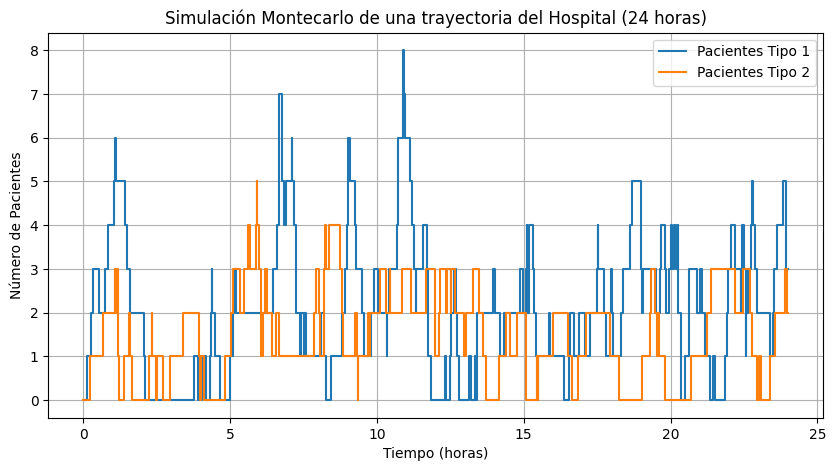

In [100]:
def simular_trayectoria_hospital(estado_inicial_idx, tiempo_max, Q):
    """
    Simula una trayectoria de la CMTC del hospital usando Montecarlo.
    Retorna los tiempos de los eventos y la secuencia de estados visitados.
    """
    tiempos = [0.0]
    estados = [estado_inicial_idx]
    
    t_actual = 0.0
    estado_actual = estado_inicial_idx
    
    while t_actual < tiempo_max:
        # Tasa total de salida del estado actual (-Q[i,i])
        tasa_salida = -Q[estado_actual, estado_actual]
        
        # 1. Generar el tiempo hasta la próxima transición (distribución exponencial)
        dt = np.random.exponential(scale=1/tasa_salida)
        t_actual += dt
        
        if t_actual > tiempo_max:
            break
            
        # 2. Determinar a qué estado transita
        tasas_transicion = Q[estado_actual, :].copy()
        tasas_transicion[estado_actual] = 0 # Ignorar la diagonal
        probabilidades = tasas_transicion / tasa_salida
        
        siguiente_estado = np.random.choice(len(Q), p=probabilidades)
        
        tiempos.append(t_actual)
        estados.append(siguiente_estado)
        estado_actual = siguiente_estado
        
    # Añadir el punto final para propósitos de la gráfica
    tiempos.append(tiempo_max)
    estados.append(estado_actual)
    
    return tiempos, estados

# --- Visualizar una trayectoria aleatoria ---
np.random.seed(0)
t, e = simular_trayectoria_hospital(index(0, 0), tiempo_max=24, Q=Q_evaluar)

# Recuperar la cantidad de pacientes basándonos en el índice
pacientes_t1 = [est // (B - b + 1) for est in e]
pacientes_t2 = [est % (B - b + 1) for est in e]

plt.figure(figsize=(10, 5))
plt.step(t, pacientes_t1, where='post', label='Pacientes Tipo 1')
plt.step(t, pacientes_t2, where='post', label='Pacientes Tipo 2')
plt.xlabel('Tiempo (horas)')
plt.ylabel('Número de Pacientes')
plt.title('Simulación Montecarlo de una trayectoria del Hospital (24 horas)')
plt.legend()
plt.grid(True)
plt.show()

#### Comparación: Probabilidad Transitoria Simulada vs Analítica
Para estimar la probabilidad del estado transitorio (1,3) por simulación, podemos correr múltiples escenarios y contar la proporción de simulaciones que terminan en el estado (1,3) exactamente en la hora 6.

In [ ]:
N_simulaciones = 10000
tiempo_objetivo = 6
estado_inicial = index(0, 0)
estado_objetivo = index(1, 3)

exitos = 0

for _ in range(N_simulaciones):
    # Simulamos solo hasta t=6
    _, e_sim = simular_trayectoria_hospital(estado_inicial, tiempo_objetivo, Q_evaluar)
    
    # Verificamos el estado en el que quedó el sistema en t=6
    if e_sim[-1] == estado_objetivo:
        exitos += 1

prob_estimada = exitos / N_simulaciones

print(f"Probabilidad de (1,3) a las 6h (Analítica): {prob_1_3:.6f}")
print(f"Probabilidad de (1,3) a las 6h (Simulada con N={N_simulaciones}): {prob_estimada:.6f}")

Probabilidad de (1,3) a las 6h (Analítica): 0.048836
Probabilidad de (1,3) a las 6h (Simulada con N=10000): 0.049500


<h5 style="color: #ADD8E6;">3. Cálculo de la probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas, partiendo de que el hospital tenía 1 paciente tipo 1 y 1 paciente tipo 2.</h5>



Para la pregunta anterior nso pedían la transición de un estado inicial a un estado final en un lapso de tiempo definido. No obstante, para esta pregunta si bien tenemos el estado inicial, y el tiempo que transcurre bien definidos, el estado final solo nos está fijando el numero de pacientes tipo 2 (como 4 pacientes), pero no nos dicen nada respecto a los pacientes tipo 1. Dado que no está especificado debemos tener en cuenta todas las combinaciones en que tenemos 4 pacientes de tipo 2 y cualquier valor $S_X=\{0,\ 1,\ 2,\ 3,\ \ldots,B\}$ para los pacientes tipo 1. 


Para poder encontrar este valor el primer paso es establecer el vector de estado inicial con 1 paciente de tipo 1 y 1 paciente de tipo 2.

In [ ]:
# --------------------------------------------------------------------
# Pregunta 3: ¿Cuál es la probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas?
# Partiendo de que el hospital tenía 1 paciente tipo 1 y 1 paciente tipo 2.
alpha = np.zeros(num_estados)
alpha[index(1,1)] = 1

Calculamos la distribución del sistema a las 5 horas.

In [8]:
probs_transitorias_5h = hospital_chain.transient_probabilities(t=5, alpha=alpha)

Para responder a la pregunta debemos sumar las probabilidades de los estados en los que hay 4 pacientes tipo 2.

In [9]:
# Sumamos las probabilidades de todos los estados en los que j == 4 (independientemente de i)
prob_4_tipo2 = sum(probs_transitorias_5h[index(i, 4)] for i in range(B + 1))
print(f"Probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas: {prob_4_tipo2:.6f}")

Probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas: 0.090174


<h5 style="color: #ADD8E6;">4. Cálculo de la varianza del número total de pacientes tras 1 hora y tras 6 horas</h5>

Para calcular la varianza podemos utilizar la fórmula de momentos $E[(\text{Total de pacientes})]$ y $E[(\text{Total de pacientes})^2]$ a la 1 y 6 horas.

La varianza se define como:
        $$
        \operatorname{Var}(\text{Pacientes}) = E[(\text{Pacientes})^2] - \Bigl(E[\text{Pacientes}]\Bigr)^2,
        $$

        
Dado que ya habíamos definido el vector de probabilidades para 6 horas en el punto 2, solo es necesario que definamos el vector tras 1 hora:

In [10]:
# Probabilidades transitorias en 1 hora
alpha = np.zeros(num_estados)
alpha[index(0, 0)] = 1
probs_transitorias_1h = hospital_chain.transient_probabilities(t=1, alpha=alpha)

Para la siguiente parte podemos definir una función que calcule la varianza en términos del valor esperado.

In [11]:
# Función para calcular varianza dada una distribución de probabilidad
def calcular_varianza(probs):
    esperanza = sum((i + j) * probs[index(i, j)]
                    for i in range(B + 1)
                    for j in range(B - b + 1))
    
    esperanza_cuadrado = sum(probs[index(i, j)] * (i + j) ** 2
                             for i in range(B + 1)
                             for j in range(B - b + 1))
    varianza = esperanza_cuadrado - esperanza ** 2
    return varianza

Ahora respondemos a la pregunta llamando esa función y utilizando como parámetro los dos vectores de probabilidades pasadas 1 hora y 6 horas:

In [12]:
# Cálculo de varianza en los distintos momentos
varianza_1h = calcular_varianza(probs_transitorias_1h)
varianza_6h = calcular_varianza(probs_transitorias_6h)

# Mostrar resultados
print(f"Varianza del número de pacientes tras 1 hora: {varianza_1h:.3f}")
print(f"Varianza del número de pacientes tras 6 horas: {varianza_6h:.3f}")

Varianza del número de pacientes tras 1 hora: 3.283
Varianza del número de pacientes tras 6 horas: 4.000


<h5 style="color: #ADD8E6;">5. Generación de la gráfica de la probabilidad de que haya más pacientes tipo 1 que tipo 2 en función del tiempo (0 a 24 horas)</h5>

Para este punto calculamos inicialmente la probabilidad para cada punto de tiempo en el intervalo de 0 a 24 horas. Esto lo guardamos en un vector que graficamos de la sigueinte forma utilizando `matplotlib`:

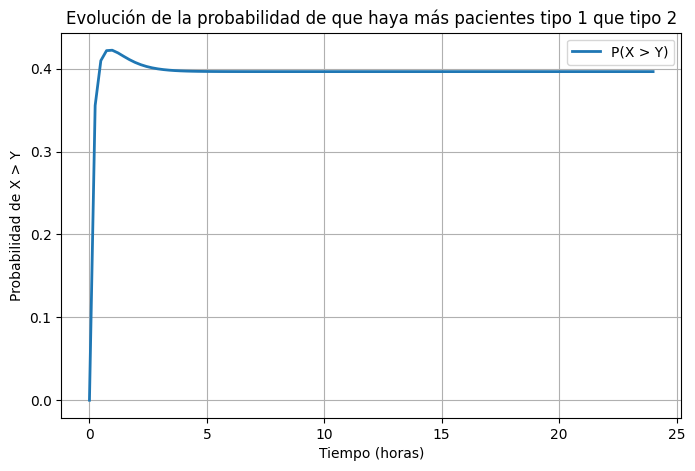

In [13]:
# --------------------------------------------------------------------
### Pregunta 5: Evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2
# Definir tiempos de evaluación
puntos_de_tiempo = np.linspace(0, 24, 100)

# Calcular la distribución transitoria para cada punto en el tiempo
probabilidad_mas_tipo_1 = []

for t in puntos_de_tiempo:
    probs_transitorias_t = hospital_chain.transient_probabilities(t=t, alpha=alpha)
    prob_mas_1 = sum(probs_transitorias_t[index(i, j)]
                     for i in range(B + 1)
                     for j in range(B - b + 1)
                     if i > j)
    probabilidad_mas_tipo_1.append(prob_mas_1)

# Graficar la evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2
plt.figure(figsize=(8, 5))
plt.plot(puntos_de_tiempo, probabilidad_mas_tipo_1, label="P(X > Y)", linewidth=2)
plt.xlabel("Tiempo (horas)")
plt.ylabel("Probabilidad de X > Y")
plt.title("Evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2")
plt.legend()
plt.grid(True)
plt.show()

<h5 style="color: #ADD8E6;">Cálculo teórico del estado estable para la condición $X > Y$</h5>

Para calcular el valor teórico a largo plazo (estado estable) de que haya más pacientes tipo 1 que tipo 2, primero definimos $\pi_{(i,j)}$ como la probabilidad límite de que el sistema se encuentre en el estado con $i$ pacientes de tipo 1 y $j$ pacientes de tipo 2.

Estas probabilidades se obtienen al resolver el sistema de ecuaciones de balance global de la cadena:

$$
\pi \mathbb{Q} = 0
$$

Sujeto a la restricción de normalización, donde la suma de todas las probabilidades debe ser igual a 1:

$$
\sum_{i=0}^{B} \sum_{j=0}^{B-b} \pi_{(i,j)} = 1
$$

Una vez hallado el vector de probabilidades en estado estable $\pi$, la probabilidad de que haya estrictamente más pacientes tipo 1 que tipo 2 en el largo plazo se define como la suma de las probabilidades de todos los estados $(i,j)$ que cumplen la condición $i > j$:

$$
\lim_{t \to \infty} P(X(t) > Y(t)) = \sum_{(i,j) \in S, i > j} \pi_{(i,j)}
$$

Lo cual, desarrollando los límites de las sumatorias para nuestro espacio de estados, equivale a:

$$
P(X > Y) = \sum_{i=1}^{B} \sum_{j=0}^{\min(i-1, B-b)} \pi_{(i,j)}
$$

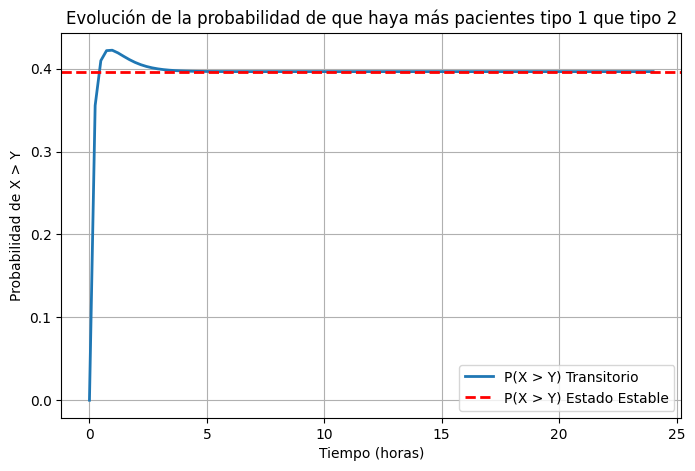

In [14]:
# --------------------------------------------------------------------
### Pregunta 5: Evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2
# Definir tiempos de evaluación
puntos_de_tiempo = np.linspace(0, 24, 100)

# Calcular la distribución transitoria para cada punto en el tiempo
probabilidad_mas_tipo_1 = []

for t in puntos_de_tiempo:
    probs_transitorias_t = hospital_chain.transient_probabilities(t=t, alpha=alpha)
    prob_mas_1 = sum(probs_transitorias_t[index(i, j)]
                     for i in range(B + 1)
                     for j in range(B - b + 1)
                     if i > j)
    probabilidad_mas_tipo_1.append(prob_mas_1)

# ----------------- NUEVO: Cálculo del Estado Estable -----------------
# Calcular la distribución en estado estable
pi_estable = hospital_chain.steady_state()

# Sumar las probabilidades donde i > j en estado estable
prob_mas_1_estable = sum(pi_estable[index(i, j)]
                         for i in range(B + 1)
                         for j in range(B - b + 1)
                         if i > j)
# ---------------------------------------------------------------------

# Graficar la evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2
plt.figure(figsize=(8, 5))
plt.plot(puntos_de_tiempo, probabilidad_mas_tipo_1, label="P(X > Y) Transitorio", linewidth=2)

# Añadir la línea horizontal roja para el estado estable
plt.axhline(y=prob_mas_1_estable, color='r', linestyle='--', label="P(X > Y) Estado Estable", linewidth=2)

plt.xlabel("Tiempo (horas)")
plt.ylabel("Probabilidad de X > Y")
plt.title("Evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2")
plt.legend()
plt.grid(True)
plt.show()

### Comportamiento en Estado Estable: Distribución Límite Simulada

En el largo plazo, el sistema alcanza un **estado estable**. Esto significa que la proporción de tiempo que la cadena pasa en cada estado converge a la probabilidad de estado estable $\pi$. 
Podemos demostrar esto simulando una única trayectoria muy larga (10,000 horas) y calculando la proporción total de tiempo que el hospital estuvo en cada estado empíricamente.

In [57]:
# Simulamos una trayectoria muy larga
tiempo_largo = 10000
t_largo, e_largo = simular_trayectoria_hospital(index(0, 0), tiempo_largo, Q_evaluar)

# Arreglo para acumular el tiempo total de ocupación de cada estado
tiempo_ocupacion = np.zeros(num_estados)

for k in range(len(t_largo) - 1):
    estado = e_largo[k]
    tiempo_estadia = t_largo[k+1] - t_largo[k]
    tiempo_ocupacion[estado] += tiempo_estadia

# Distribución empírica (proporción del tiempo en cada estado)
pi_simulado = tiempo_ocupacion / tiempo_largo

# --- Solución Analítica con jmarkov ---
pi_analitico = hospital_chain.steady_state()

# Imprimir una muestra comparativa de un estado arbitrario, por ejemplo (5,3)
idx_muestra = index(5, 3)
print(f"Probabilidad estado estable para (5,3) [Analítico]: {pi_analitico[idx_muestra]:.4f}")
print(f"Probabilidad estado estable para (5,3) [Simulado]:  {pi_simulado[idx_muestra]:.4f}")

Probabilidad estado estable para (5,3) [Analítico]: 0.0065
Probabilidad estado estable para (5,3) [Simulado]:  0.0063


### Tiempos de Primera Pasada

El **Hitting Time** es el valor esperado del tiempo que tarda el sistema en alcanzar por primera vez un estado objetivo, asumiendo que arranca desde un estado inicial específico.

> **¡Advertencia práctica!** Simular el tiempo de llegada a un estado "raro" o muy lejano requiere que la simulación corra durante mucho tiempo, por lo que el código podría tardar demasiado en terminar. Para propósitos educativos, estimaremos por simulación el tiempo que tarda el hospital en ir de estar vacío **(0,0)** a tener 3 pacientes tipo 1 y 2 tipo 2 **(3,2)**.

In [28]:
def simular_hitting_time(estado_inicial_idx, estado_objetivo_idx, Q):
    """
    Simula la cadena hasta tocar el estado objetivo y retorna el tiempo tomado.
    """
    t_actual = 0.0
    estado_actual = estado_inicial_idx
    
    while estado_actual != estado_objetivo_idx:
        tasa_salida = -Q[estado_actual, estado_actual]
            
        dt = np.random.exponential(scale=1/tasa_salida)
        t_actual += dt
        
        tasas_transicion = Q[estado_actual, :].copy()
        tasas_transicion[estado_actual] = 0
        probabilidades = tasas_transicion / tasa_salida
        
        estado_actual = np.random.choice(len(Q), p=probabilidades)
        
    return t_actual

# Simulación de Montecarlo
N_hitting = 500
estado_inicio = index(0, 0)
estado_meta = index(3, 2)

tiempos_llegada = []

for _ in range(N_hitting):
    t_llegada = simular_hitting_time(estado_inicio, estado_meta, Q_evaluar)
    tiempos_llegada.append(t_llegada)

tiempo_esperado_simulado = np.mean(tiempos_llegada)

# Solución Analítica usando jmarkov
hitting_time_analitico = hospital_chain.first_passage_time(estado_meta)
tiempo_esperado_analitico = hitting_time_analitico[estado_inicio][0]

print(f"Tiempo esperado de (0,0) a (3,2) (Analítico): {tiempo_esperado_analitico:.4f} horas")
print(f"Tiempo esperado de (0,0) a (3,2) (Simulado): {tiempo_esperado_simulado:.4f} horas")

Tiempo esperado de (0,0) a (3,2) (Analítico): 2.5165 horas
Tiempo esperado de (0,0) a (3,2) (Simulado): 2.5066 horas


<h4 style="color: #ADD8E6;">Parte C. Análisis a largo plazo y tiempos de transición</h4>

A partir de la cadena de Markov construida, utilice las funciones integradas de la librería para resolver las siguientes preguntas:

6. **Estado Estable y Costos:** Calcule la distribución de probabilidad en estado estable. Si cada paciente tipo 1 genera un costo operativo por insumos de 100 pesos por hora y cada paciente tipo 2 un costo de 80 pesos por hora, ¿cuál es el costo operativo total esperado por hora en el largo plazo?
7. **Tiempo de Primera Pasada:** Si actualmente el hospital se encuentra completamente vacío, ¿cuánto tiempo pasará en promedio para que se alcance por primera vez un estado con 10 pacientes tipo 1 y 5 pacientes tipo 2?
8. **Tiempo de Ocupación:** Si se observa la cadena durante un día completo (24 horas), ¿cuánto tiempo durará el hospital completamente vacío dado que actualmente hay 1 paciente de tipo 1 y 1 paciente de tipo 2?

<h5 style="color: #ADD8E6;">6. Cálculo del costo operativo esperado en estado estable</h5>

Para encontrar el comportamiento a largo plazo, calculamos la distribución límite utilizando el método `.steady_state()`. Posteriormente, multiplicamos este vector de probabilidades por un vector con los costos asociados a cada estado y sumamos los valores para hallar el valor esperado.

In [15]:
# --------------------------------------------------------------------
# Pregunta 6: Costo esperado a largo plazo usando estado estable

# Obtener vector de probabilidades en estado estable
probs_estable = hospital_chain.steady_state()

# Construir el vector de costos para cada estado (i pacientes tipo 1, j pacientes tipo 2)
costos_estados = np.zeros(num_estados)
for i in range(B + 1):
    for j in range(B - b + 1):
        costos_estados[index(i, j)] = (100 * i) + (80 * j)

# El costo esperado es la suma del producto de las probabilidades límite y los costos
costo_esperado_largo_plazo = sum(probs_estable * costos_estados)

print(f"Costo operativo total esperado por hora: ${costo_esperado_largo_plazo:.2f}")

Costo operativo total esperado por hora: $360.00


<h5 style="color: #ADD8E6;">7. Tiempo esperado de primera pasada al estado (1, 3)</h5>

Utilizamos el método `.first_passage_time()` de la cadena para obtener la matriz de tiempos promedios de primera visita y extraemos el valor correspondiente al viaje desde el estado $(0,0)$ hasta el estado $(1,3)$.

In [ ]:
# --------------------------------------------------------------------
# Pregunta 7: Tiempo esperado de primera pasada

idx_vacio = index(0, 0)
idx_objetivo = index(1, 3)

# La función first_passage_time recibe el estado objetivo (target) como argumento.
# Retorna un arreglo con los tiempos desde cada posible estado inicial.
tiempo_0_a_10_5 = hospital_chain.first_passage_time(idx_objetivo)[idx_vacio]


print(f"Tiempo esperado hasta tener 10 pacientes tipo 1 y 5 tipo 2: {tiempo_0_a_10_5[0]:.4f} horas")

Tiempo esperado hasta tener 10 pacientes tipo 1 y 5 tipo 2: 2.8770 horas


<h5 style="color: #ADD8E6;">8. Tiempo de ocupación en estado vacío durante 24 horas</h5>

Aplicamos el método `.occupation_time(t)` para un periodo de $t=24$ horas. Esta función nos devuelve una matriz donde podemos ubicar el tiempo esperado que la cadena pasa en el estado $(0,0)$ si partimos del estado $(1,1)$.

In [17]:
# --------------------------------------------------------------------
# Pregunta 8: Tiempo de ocupación

idx_vacio = index(0, 0)
idx_inicial = index(1, 1)

# Generar la matriz de tiempos de ocupación para 24 horas
matriz_ocupacion = hospital_chain.occupation_time(24)

# Extraer el tiempo en el estado objetivo (idx_vacio) asumiendo que arranca en el inicial (idx_inicial)
# Se utiliza la indexación [fila, columna]
tiempo_vacio_24h = matriz_ocupacion[idx_inicial, idx_vacio]

print(f"Tiempo esperado que el hospital estará vacío durante 24 horas: {tiempo_vacio_24h:.4f} horas")

Tiempo esperado que el hospital estará vacío durante 24 horas: 0.4520 horas


### Simulación de Tiempos de Ocupación (Montecarlo)

El tiempo de ocupación nos dice cuánto tiempo esperado pasará la cadena en un subconjunto de estados (en este caso, el hospital vacío) dado un horizonte de tiempo y un estado inicial.

Para calcularlo mediante **simulación de Montecarlo**, el procedimiento empírico es:
1. Simular múltiples trayectorias ($N$ iteraciones) durante el tiempo estipulado (24 horas) arrancando siempre desde el estado inicial dado `(1,1)`.
2. Para cada trayectoria, iterar por los tiempos de los eventos y sumar la duración $(\Delta t = t_{k+1} - t_k)$ exclusivamente cuando el estado de la cadena sea el estado objetivo `(0,0)`.
3. Promediar el tiempo de ocupación obtenido en todas las trayectorias para obtener el valor esperado empírico.

In [61]:
# Parámetros de la simulación
N_ocupacion = 1000  # Número de simulaciones de Montecarlo
tiempo_horizonte = 24
estado_arranque = index(1, 1)
estado_meta = index(0, 0)

tiempos_ocupacion_acumulados = []

for _ in range(N_ocupacion):
    # Usamos la función de simulación que creamos en la Parte 1
    t_sim, e_sim = simular_trayectoria_hospital(estado_arranque, tiempo_horizonte, Q_evaluar)
    
    tiempo_en_vacio = 0.0
    
    # Recorrer la trayectoria para sumar los intervalos de tiempo donde el estado fue (0,0)
    for k in range(len(t_sim) - 1):
        if e_sim[k] == estado_meta:
            # El tiempo de permanencia es la diferencia entre el evento k+1 y el evento k
            tiempo_en_vacio += (t_sim[k+1] - t_sim[k])
            
    tiempos_ocupacion_acumulados.append(tiempo_en_vacio)

# Calcular el valor esperado (promedio) de la simulación
tiempo_esperado_ocupacion_sim = np.mean(tiempos_ocupacion_acumulados)

print(f"Tiempo esperado que el hospital estará vacío durante 24h (Analítico): {tiempo_vacio_24h:.4f} horas")
print(f"Tiempo esperado que el hospital estará vacío durante 24h (Simulado):  {tiempo_esperado_ocupacion_sim:.4f} horas")

Tiempo esperado que el hospital estará vacío durante 24h (Analítico): 0.4520 horas
Tiempo esperado que el hospital estará vacío durante 24h (Simulado):  0.4511 horas


Universidad de los Andes | Vigilada Mineducación. Reconocimiento como Universidad: Decreto 1297 del 30 de mayo de 1964. Reconocimiento personería jurídica: Resolución 28 del 23 de febrero de 1949 Minjusticia. Departamento de Ingeniería Industrial Carrera 1 Este No. 19 A 40 Bogotá, Colombia Tel. (57.1) 3324320 | (57.1) 3394949 Ext. 2880 /2881 http://industrial.uniandes.edu.co